In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as transforms
import numpy as np
import os
import json
from typing import List, Tuple
from base import BaseDataLoader

class IIDFEMNISTDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = []
        self.targets = []
        for x, y in zip(data['x'], data['y']):
            self.data.append(torch.tensor(x).reshape(28, 28).unsqueeze(0))
            self.targets.append(y)
        self.transform = transform

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = self.data[idx]
        target = self.targets[idx]
        
        if self.transform:
            img = img  # no transformation needed since data is already normalized
            
        return img, target

class IIDFEMNISTDataLoader(BaseDataLoader):
    def __init__(self, data_dir: str, n_clients: int, batch_size: int):
        super().__init__(data_dir, n_clients, batch_size)
        self.transform = transforms.Compose([
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        self.json_dir = os.path.join(data_dir, "all_data")
        
    def load_all_data(self):
        """Load and combine all data from JSON files"""
        all_data = {'x': [], 'y': []}
        
        # Iterate through all JSON files in the directory
        for filename in os.listdir(self.json_dir):
            if not filename.endswith('.json') or filename == 'user_index.json':
                continue
                
            filepath = os.path.join(self.json_dir, filename)
            with open(filepath, 'r') as f:
                data = json.load(f)
                
                # Combine data from all users
                for user_id, user_data in data['user_data'].items():
                    all_data['x'].extend(user_data['x'])
                    all_data['y'].extend(user_data['y'])
        
        return all_data

    def load_data(self) -> Tuple[List[DataLoader], DataLoader, DataLoader, List[float], int]:
        """Load and prepare the dataset with IID distribution"""
        try:
            # Load all data
            all_data = self.load_all_data()
            total_samples = len(all_data['y'])
            
            if total_samples == 0:
                raise ValueError("No data loaded")
            
            # Create the complete dataset
            full_dataset = IIDFEMNISTDataset(all_data, self.transform)
            
            # Create validation and test sets (10% each)
            val_size = min(int(0.1 * total_samples), 1000)
            test_size = min(int(0.1 * total_samples), 1000)
            train_size = total_samples - val_size - test_size
            
            # Split indices
            indices = np.random.permutation(total_samples)
            train_indices = indices[:train_size]
            val_indices = indices[train_size:train_size + val_size]
            test_indices = indices[train_size + val_size:]
            
            # Create validation and test datasets
            val_dataset = Subset(full_dataset, val_indices)
            test_dataset = Subset(full_dataset, test_indices)
            
            # Split training data among clients
            samples_per_client = train_size // self.n_clients
            train_loaders = []
            client_weights = []
            
            for i in range(self.n_clients):
                start_idx = i * samples_per_client
                end_idx = start_idx + samples_per_client if i < self.n_clients - 1 else len(train_indices)
                client_indices = train_indices[start_idx:end_idx]
                
                client_dataset = Subset(full_dataset, client_indices)
                client_loader = DataLoader(
                    client_dataset,
                    batch_size=self.batch_size,
                    shuffle=True
                )
                train_loaders.append(client_loader)
                client_weights.append(len(client_indices) / train_size)
            
            # Create validation and test loaders
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
            test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
            
            # Store client weights for later use
            self._client_weights = client_weights
            
            return train_loaders, val_loader, test_loader, client_weights, 1
            
        except Exception as e:
            raise Exception(f"Failed to load data: {str(e)}")

    @property
    def client_weights(self):
        """Get the weights of clients"""
        if hasattr(self, '_client_weights'):
            return self._client_weights
        return None

In [2]:
# First, let's import necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import json
import os

# Initialize the dataloader
data_dir = "../data/FEMNIST"
n_clients = 5  # We'll use 5 clients for this analysis
batch_size = 32

dataloader = IIDFEMNISTDataLoader(data_dir, n_clients, batch_size)
train_loaders, val_loader, test_loader, client_weights, _ = dataloader.load_data()

# Let's analyze the distribution of data
client_stats = []
for i, loader in enumerate(train_loaders):
    # Count samples per class for this client
    class_counts = Counter()
    total_samples = 0
    
    for _, labels in loader:
        for label in labels:
            class_counts[label.item()] += 1
            total_samples += 1
    
    client_stats.append({
        'client_id': i,
        'total_samples': total_samples,
        'class_distribution': dict(class_counts),
        'weight': client_weights[i]
    })
    
    print(f"\nClient {i} Statistics:")
    print(f"Total samples: {total_samples}")
    print(f"Weight: {client_weights[i]:.4f}")
    print("Class distribution:")
    for class_id, count in sorted(class_counts.items()):
        print(f"Class {class_id}: {count} samples ({count/total_samples*100:.2f}%)")

# Analyze validation and test sets
val_stats = Counter()
test_stats = Counter()
val_samples = 0
test_samples = 0

for _, labels in val_loader:
    for label in labels:
        val_stats[label.item()] += 1
        val_samples += 1

for _, labels in test_loader:
    for label in labels:
        test_stats[label.item()] += 1
        test_samples += 1

print("\nValidation Set Statistics:")
print(f"Total samples: {val_samples}")
for class_id, count in sorted(val_stats.items()):
    print(f"Class {class_id}: {count} samples ({count/val_samples*100:.2f}%)")

print("\nTest Set Statistics:")
print(f"Total samples: {test_samples}")
for class_id, count in sorted(test_stats.items()):
    print(f"Class {class_id}: {count} samples ({count/test_samples*100:.2f}%)")


Client 0 Statistics:
Total samples: 157732
Weight: 0.2000
Class distribution:
Class 0: 8019 samples (5.08%)
Class 1: 8678 samples (5.50%)
Class 2: 7886 samples (5.00%)
Class 3: 8005 samples (5.08%)
Class 4: 7604 samples (4.82%)
Class 5: 7165 samples (4.54%)
Class 6: 7881 samples (5.00%)
Class 7: 8211 samples (5.21%)
Class 8: 7788 samples (4.94%)
Class 9: 7718 samples (4.89%)
Class 10: 1469 samples (0.93%)
Class 11: 900 samples (0.57%)
Class 12: 2280 samples (1.45%)
Class 13: 1033 samples (0.65%)
Class 14: 1114 samples (0.71%)
Class 15: 2082 samples (1.32%)
Class 16: 565 samples (0.36%)
Class 17: 729 samples (0.46%)
Class 18: 2634 samples (1.67%)
Class 19: 862 samples (0.55%)
Class 20: 576 samples (0.37%)
Class 21: 1131 samples (0.72%)
Class 22: 1976 samples (1.25%)
Class 23: 1840 samples (1.17%)
Class 24: 5538 samples (3.51%)
Class 25: 1962 samples (1.24%)
Class 26: 590 samples (0.37%)
Class 27: 1129 samples (0.72%)
Class 28: 4456 samples (2.83%)
Class 29: 2183 samples (1.38%)
Class 3

In [3]:
# Chi-square test to check if distributions are similar across clients
from scipy.stats import chi2_contingency

# Create a matrix of class distributions for all clients
class_distribution_matrix = []
for stats in client_stats:
    distribution = []
    for class_id in range(max(stats['class_distribution'].keys()) + 1):
        distribution.append(stats['class_distribution'].get(class_id, 0))
    class_distribution_matrix.append(distribution)

# Perform chi-square test
chi2, p_value, _, _ = chi2_contingency(class_distribution_matrix)
print(f"\nChi-square test for IID distribution:")
print(f"p-value: {p_value:.4f}")
print(f"The distribution is {'likely IID' if p_value > 0.05 else 'likely not IID'}")

# Calculate Jensen-Shannon divergence between clients
from scipy.spatial.distance import jensenshannon

print("\nJensen-Shannon divergence between clients:")
for i in range(len(client_stats)):
    for j in range(i+1, len(client_stats)):
        dist_i = np.array(list(client_stats[i]['class_distribution'].values()))
        dist_j = np.array(list(client_stats[j]['class_distribution'].values()))
        
        # Normalize distributions
        dist_i = dist_i / dist_i.sum()
        dist_j = dist_j / dist_j.sum()
        
        js_div = jensenshannon(dist_i, dist_j)
        print(f"Clients {i} and {j}: {js_div:.4f}")


Chi-square test for IID distribution:
p-value: 0.3618
The distribution is likely IID

Jensen-Shannon divergence between clients:
Clients 0 and 1: 0.3398
Clients 0 and 2: 0.3173
Clients 0 and 3: 0.3247
Clients 0 and 4: 0.3340
Clients 1 and 2: 0.3799
Clients 1 and 3: 0.3525
Clients 1 and 4: 0.3140
Clients 2 and 3: 0.3069
Clients 2 and 4: 0.3502
Clients 3 and 4: 0.3614


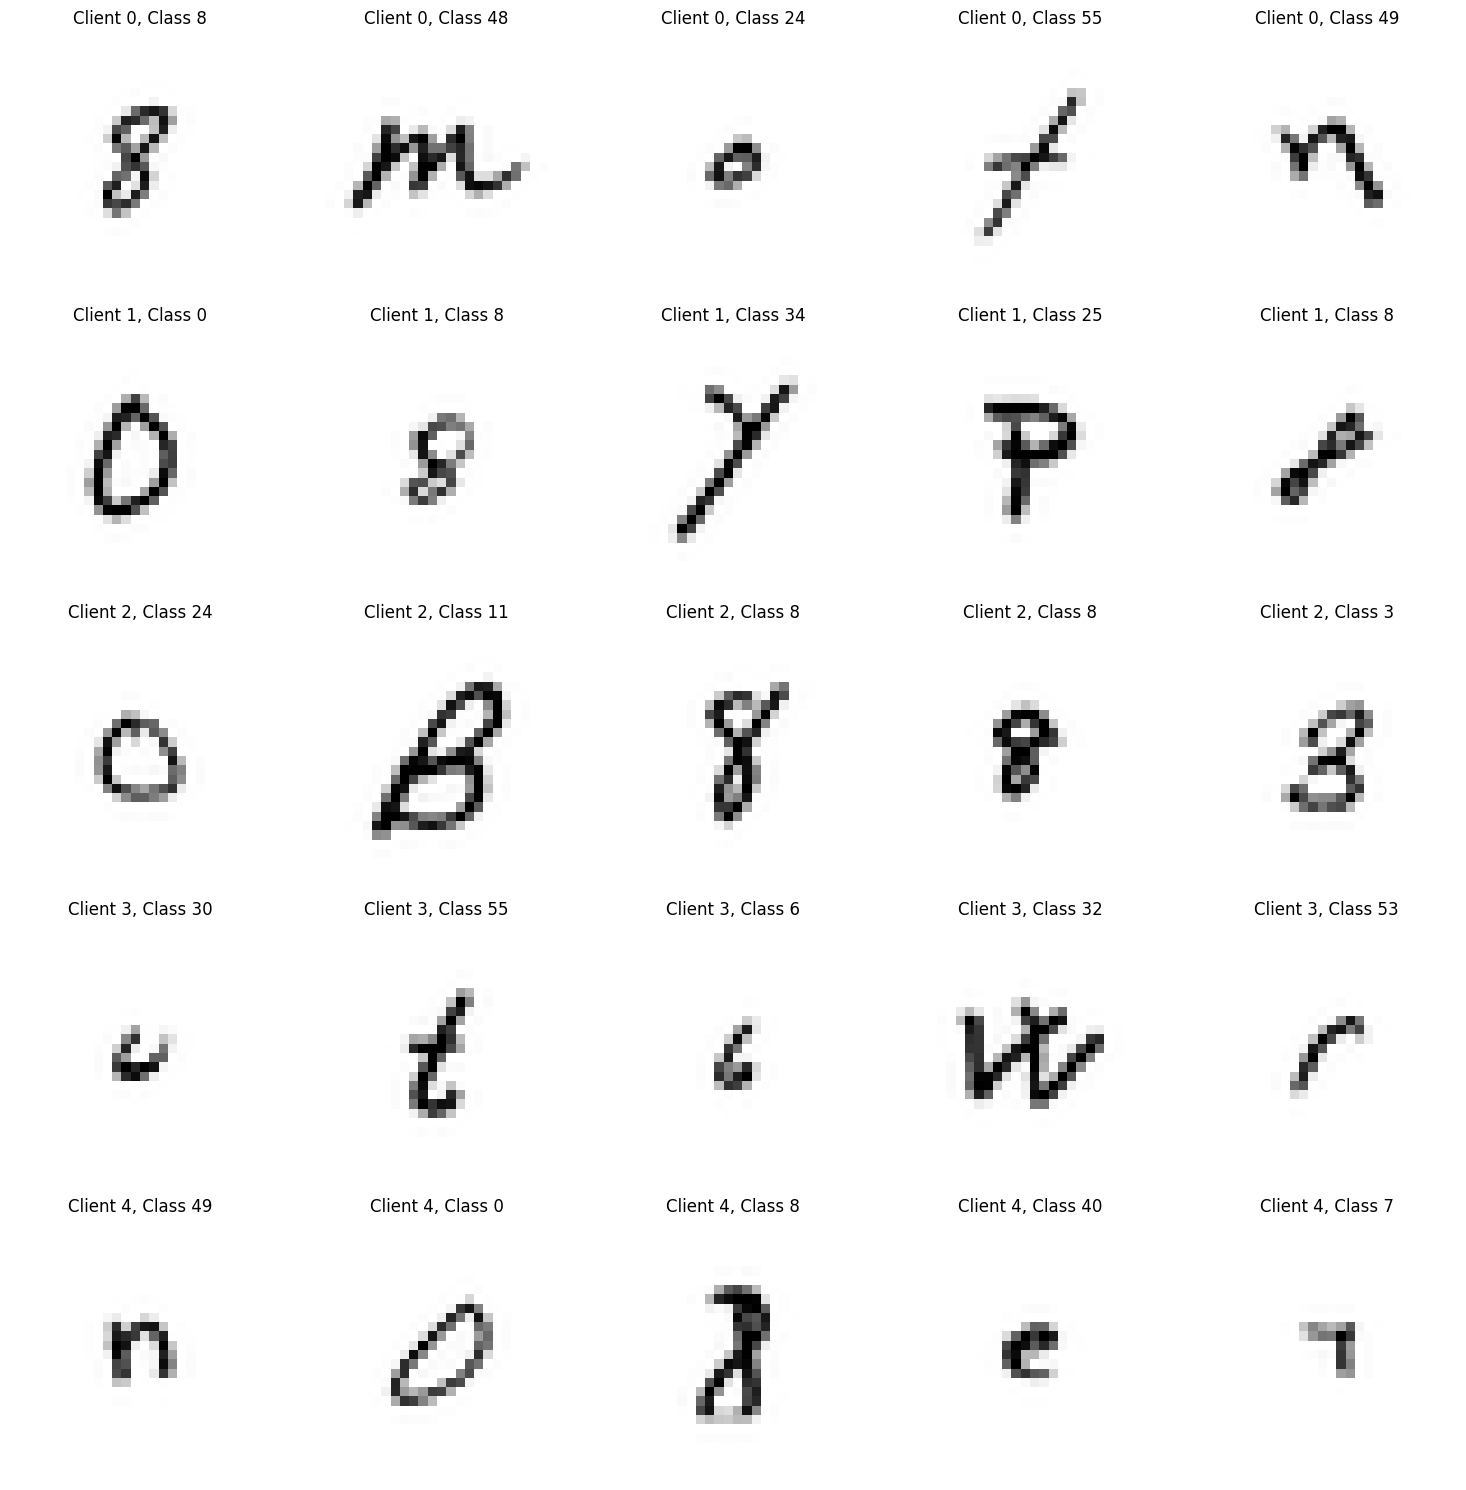

In [4]:
# Plot sample images from each client
plt.figure(figsize=(15, 3*n_clients))
for i, loader in enumerate(train_loaders):
    images, labels = next(iter(loader))
    
    for j in range(min(5, len(images))):
        plt.subplot(n_clients, 5, i*5 + j + 1)
        plt.imshow(images[j].squeeze(), cmap='gray')
        plt.title(f'Client {i}, Class {labels[j]}')
        plt.axis('off')
plt.tight_layout()
plt.show()